In [ ]:
import pandas as pd

# 1️⃣ 读取并预处理函数
def load_and_clean(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=False)

    # 时间戳统一到微秒
    df['Close Time'] = df['Close Time'].apply(lambda x: x * 1000 + 999 if x < 2000000000000 else x)
    df['Open Time']  = df['Open Time'] .apply(lambda x: x * 1000       if x < 2000000000000 else x)

    df['Close Time'] = pd.to_datetime(df['Close Time'], unit='us')
    df['Open Time']  = pd.to_datetime(df['Open Time'],  unit='us')
    return df.set_index("Close Time")

# 2️⃣ 逐个读入
btc  = load_and_clean("/Users/lizeyu/Desktop/qoc/tmp/raw/5m_klines_raw/BTCUSDT_klines_5m.csv")
doge = load_and_clean("/Users/lizeyu/Desktop/qoc/tmp/raw/5m_klines_raw/DOGEUSDT_klines_5m.csv")
xrp  = load_and_clean("/Users/lizeyu/Desktop/qoc/tmp/raw/5m_klines_raw/XRPUSDT_klines_5m.csv")
pepe = load_and_clean("/Users/lizeyu/Desktop/qoc/tmp/raw/5m_klines_raw/PEPEUSDT_klines_5m.csv")

# 3️⃣ 找共同 index（循环交集）
common_index = set(btc.index)
for df in [doge, xrp, pepe]:
    common_index = common_index & set(df.index)

common_index = sorted(common_index)  # 转回有序列表

# 4️⃣ 循环计算两个比值序列
btc_doge_ratio = []
xrp_pepe_ratio = []

for t in common_index:
    btc_doge_ratio.append(btc.loc[t, 'Close'] / doge.loc[t, 'Close'])
    xrp_pepe_ratio.append(xrp.loc[t, 'Close'] / pepe.loc[t, 'Close'])

# 5️⃣ 生成 DataFrame
ratio_df = pd.DataFrame({
    "BTC/DOGE": btc_doge_ratio,
    "XRP/PEPE": xrp_pepe_ratio
}, index=pd.DatetimeIndex(common_index))

print(ratio_df.head())


                                 BTC/DOGE       XRP/PEPE
2023-05-05 18:04:59.999999  371985.995458  141732.522796
2023-05-05 18:09:59.999999  371690.007570  149329.073482
2023-05-05 18:14:59.999999  372179.454821  141878.787879
2023-05-05 18:19:59.999999  372411.727537  137076.023392
2023-05-05 18:24:59.999999  372646.828405  137096.774194


In [ ]:
btc.sort_index(inplace=True)
doge.sort_index(inplace=True)
xrp.sort_index(inplace=True)
pepe.sort_index(inplace=True)

btc.drop_duplicates(inplace=True)
doge.drop_duplicates(inplace=True)
xrp.drop_duplicates(inplace=True)
pepe.drop_duplicates(inplace=True)

In [46]:
btc

,index,Open Time,Open,High,Low,Close,Volume,Quote Asset Volume,Number of Trades,Taker Buy Base Volume,Taker Buy Quote Volume,Ignore
Close Time,,,,,,,,,,,,
2022-07-01 00:04:59.999999,0,2022-07-01 00:00:00,19942.21,19978.47,19671.54,19720.27,1500.73213,2.973862e+07,18444,692.71753,1.373040e+07,0
2022-07-01 00:09:59.999999,1,2022-07-01 00:05:00,19720.28,19824.99,19658.97,19779.77,945.32135,1.866176e+07,11457,487.43124,9.621930e+06,0
2022-07-01 00:14:59.999999,2,2022-07-01 00:10:00,19779.77,19812.58,19707.00,19724.38,617.76929,1.221068e+07,7521,244.41978,4.829768e+06,0
2022-07-01 00:19:59.999999,3,2022-07-01 00:15:00,19724.39,19811.69,19704.56,19795.44,464.63898,9.179269e+06,6709,225.60132,4.456851e+06,0
2022-07-01 00:24:59.999999,4,2022-07-01 00:20:00,19795.43,19813.30,19748.36,19750.16,323.53863,6.399147e+06,4252,167.23182,3.308143e+06,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31 23:39:59.999999,17851,2025-08-31 23:35:00,108251.22,108416.35,108111.00,108156.01,113.69077,1.230942e+07,16780,65.43264,7.086852e+06,0
2025-08-31 23:44:59.999999,17852,2025-08-31 23:40:00,108156.00,108258.00,108076.93,108258.00,102.71622,1.110862e+07,13502,56.70324,6.131969e+06,0
2025-08-31 23:49:59.999999,17853,2025-08-31 23:45:00,108257.99,108356.05,108194.86,108283.23,86.46452,9.361689e+06,12602,53.26288,5.766744e+06,0


In [47]:
_1st_m2m_returns = ratio_df['BTC/DOGE'].pct_change(periods=96)
_3rd_m2m_returns = ratio_df['XRP/PEPE'].pct_change(periods=96)

btc_returns = btc['Close'].pct_change(periods=96)
doge_returns = doge['Close'].pct_change(periods=96)

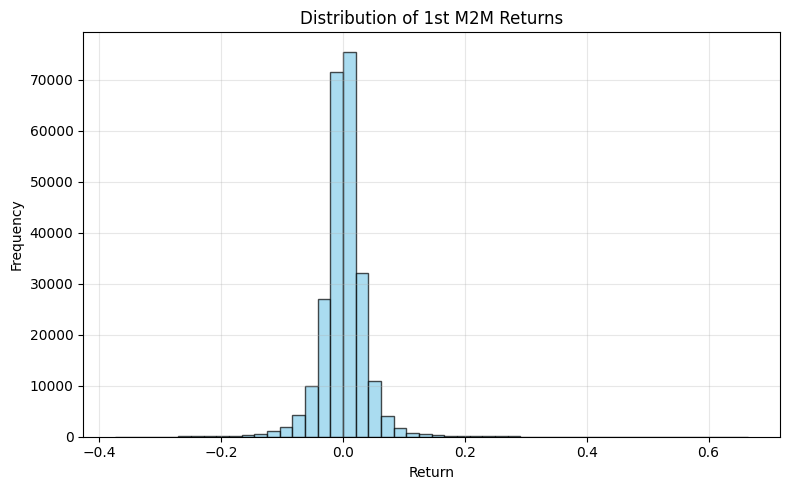

In [48]:
import matplotlib.pyplot as plt

series = _3rd_m2m_returns.dropna()   # 去掉 NaN
plt.figure(figsize=(8,5))
plt.hist(series, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.title('Distribution of 1st M2M Returns')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


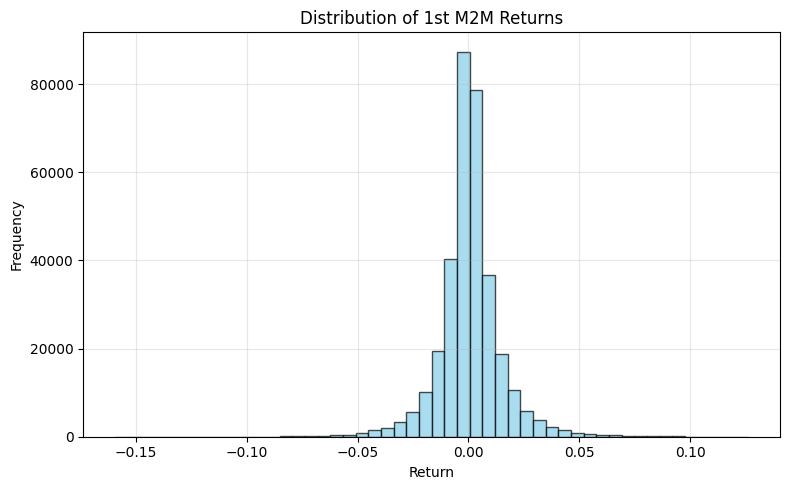

In [69]:
import matplotlib.pyplot as plt

series = btc_returns.dropna()   # 去掉 NaN
plt.figure(figsize=(8,5))
plt.hist(series, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.title('Distribution of 1st M2M Returns')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


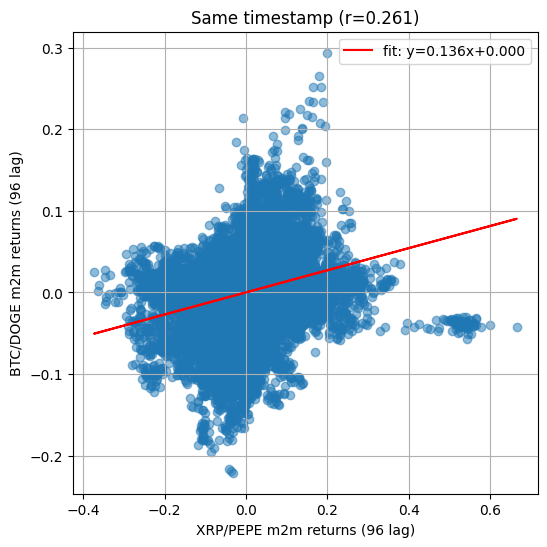

Correlation (Pearson r): 0.2609, p-value: 0


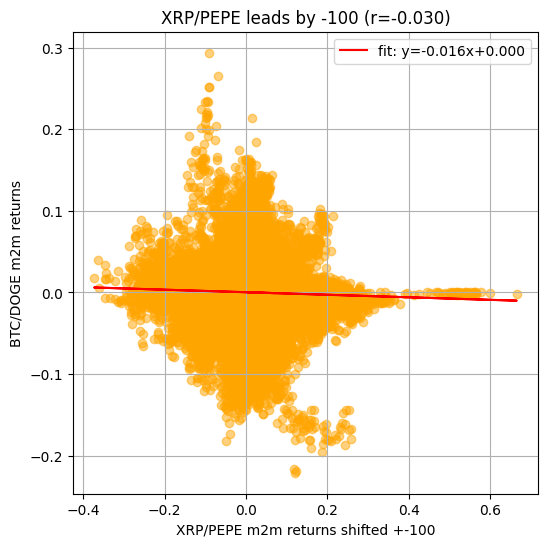

Correlation with lead -100: -0.0298, p-value: 5.53e-49


In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ================== 1️⃣ 同步散点 ==================
x = _3rd_m2m_returns
y = _1st_m2m_returns

# 删除缺失值以免影响拟合
mask = x.notna() & y.notna()
x_clean, y_clean = x[mask], y[mask]

# 线性回归
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

plt.figure(figsize=(6,6))
plt.scatter(x_clean, y_clean, alpha=0.5)
plt.plot(x_clean, slope*x_clean + intercept, color="red", label=f"fit: y={slope:.3f}x+{intercept:.3f}")
plt.xlabel("XRP/PEPE m2m returns (96 lag)")
plt.ylabel("BTC/DOGE m2m returns (96 lag)")
plt.title(f"Same timestamp (r={r_value:.3f})")
plt.legend()
plt.grid(True)
plt.show()

print(f"Correlation (Pearson r): {r_value:.4f}, p-value: {p_value:.4g}")

# ================== 2️⃣ 领先 360 散点 ==================
lead = -100
x_lead = _3rd_m2m_returns.shift(lead)
mask2 = x_lead.notna() & y.notna()
x2, y2 = x_lead[mask2], y[mask2]

slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)

plt.figure(figsize=(6,6))
plt.scatter(x2, y2, alpha=0.5, color="orange")
plt.plot(x2, slope2*x2 + intercept2, color="red",
         label=f"fit: y={slope2:.3f}x+{intercept2:.3f}")
plt.xlabel(f"XRP/PEPE m2m returns shifted +{lead}")
plt.ylabel("BTC/DOGE m2m returns")
plt.title(f"XRP/PEPE leads by {lead} (r={r_value2:.3f})")
plt.legend()
plt.grid(True)
plt.show()

print(f"Correlation with lead {lead}: {r_value2:.4f}, p-value: {p_value2:.4g}")


In [51]:
_3rd_m2m_returns.to_csv("xrp_pepe_m2m_returns.csv")

In [52]:
x_lead

2023-05-05 18:04:59.999999    0.143564
2023-05-05 18:09:59.999999    0.162846
2023-05-05 18:14:59.999999    0.134763
2023-05-05 18:19:59.999999    0.174114
2023-05-05 18:24:59.999999    0.180463
                                ...   
2025-08-31 23:39:59.999999         NaN
2025-08-31 23:44:59.999999         NaN
2025-08-31 23:49:59.999999         NaN
2025-08-31 23:54:59.999999         NaN
2025-08-31 23:59:59.999999         NaN
Name: XRP/PEPE, Length: 244584, dtype: float64

In [53]:
y

2023-05-05 18:04:59.999999         NaN
2023-05-05 18:09:59.999999         NaN
2023-05-05 18:14:59.999999         NaN
2023-05-05 18:19:59.999999         NaN
2023-05-05 18:24:59.999999         NaN
                                ...   
2025-08-31 23:39:59.999999    0.014648
2025-08-31 23:44:59.999999    0.016964
2025-08-31 23:49:59.999999    0.015925
2025-08-31 23:54:59.999999    0.015769
2025-08-31 23:59:59.999999    0.017362
Name: BTC/DOGE, Length: 244584, dtype: float64

Processing: 100%|██████████| 244584/244584 [00:00<00:00, 349668.06it/s]


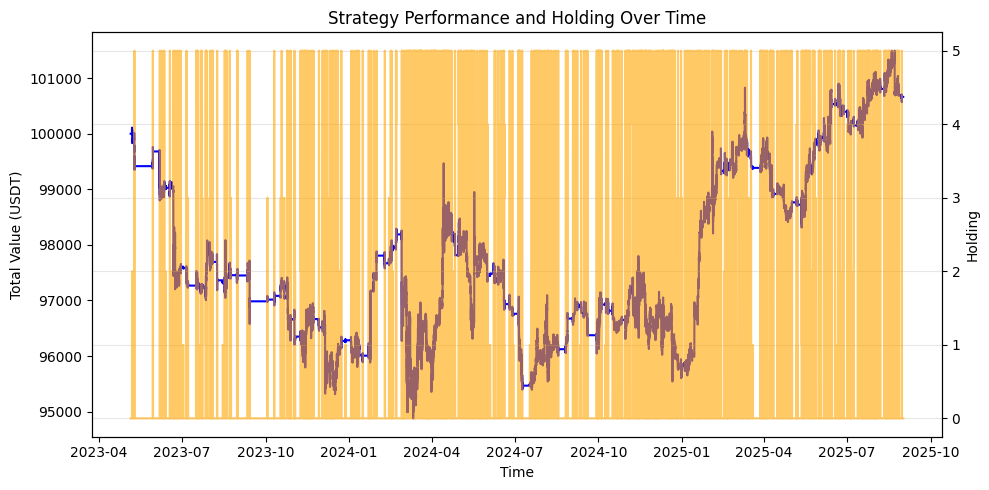

In [ ]:
import numpy as np
import pandas as pd
from collections import deque
from tqdm import tqdm

def implement_strategy(
    xrp: pd.DataFrame,
    pepe: pd.DataFrame,
    _1st_m2m_returns: pd.Series,
    delta_t: int,
    holding_period: int,
    threshold: float = 0.05,
    initial_cap: float = 100000,
    trade_size: float = 1000,
    fee: float = 0.00,
    max_hold: int = 50
):

    xrp_prices = xrp["Close"].values
    pepe_prices = pepe["Close"].values
    n = len(pepe_prices)

    # 预分配结果
    total_value = np.zeros(n)
    holdings_array = np.zeros(n)
    pnl_records = np.zeros(n)  # 每次平仓的收益率记录

    # 策略状态
    capital = initial_cap     # USDT
    b_amount = 0.0            # 持有的 XRP
    s_amount = 0.0            # 持有的 PEPE (做空数量为负)
    open_orders = deque()     # 存储未平仓订单 [{time, b_price, b_qty, s_price, s_qty}]
    now_holding = 0

    for t in tqdm(range(n), desc="Processing"):
        xrp_price_t = xrp_prices[t]
        pepe_price_t = pepe_prices[t]

        # 当前账户净值
        total_value[t] = capital + b_amount * xrp_price_t + s_amount * pepe_price_t
        holdings_array[t] = now_holding

        # --- 开仓条件：做多 XRP / 做空 PEPE ---
        if (
            t >= delta_t+holding_period 
            and _1st_m2m_returns.iloc[t-delta_t] > threshold 
            and btc_returns.iloc[t-delta_t]<threshold
            and doge_returns.iloc[t-delta_t]>-threshold
            and now_holding < max_hold
        ):
            # 买 XRP
            b_qty = trade_size / xrp_price_t
            cost = trade_size * (1 + fee)
            if capital >= cost:
                capital -= cost
                b_amount += b_qty

                # 卖空 PEPE（按同等资金规模对冲）
                s_qty = trade_size / pepe_price_t
                proceeds = s_qty * pepe_price_t * (1 - fee)
                capital += proceeds
                s_amount -= s_qty

                # 记录订单
                open_orders.append({
                    "time": t,
                    "b_price": xrp_price_t,
                    "b_qty": b_qty,
                    "s_price": pepe_price_t,
                    "s_qty": s_qty
                })
                now_holding += 1

        # --- 平仓条件 ---
        if now_holding > 0:
            while open_orders and (t - open_orders[0]["time"]) >= holding_period:
                order = open_orders.popleft()

                # 卖掉 XRP
                sell_qty = order["b_qty"]
                proceeds = sell_qty * xrp_price_t * (1 - fee)
                capital += proceeds
                b_amount -= sell_qty

                # 买回 PEPE（平空）
                buy_qty = order["s_qty"]
                cost = buy_qty * pepe_price_t * (1 + fee)
                capital -= cost
                s_amount += buy_qty

                # --- 计算 PnL ---
                entry_val = order["b_qty"] * order["b_price"] - order["s_qty"] * order["s_price"]
                exit_val  = sell_qty * xrp_price_t - buy_qty * pepe_price_t

                pnl = (exit_val - entry_val) /(2*trade_size)
                pnl_records[t] += pnl

                now_holding -= 1

    # 生成结果
    performance_df = pd.DataFrame({"Total Value": total_value}, index=pepe.index)
    holding_series = pd.Series(holdings_array, index=pepe.index)
    pnl_series = pd.Series(pnl_records, index=pepe.index)
    return performance_df, pnl_series, holding_series

# 运行优化后的策略
strategy_performance, pnls, holding = implement_strategy(
    xrp, pepe, _1st_m2m_returns,
    # btc, doge, _3rd_m2m_returns,
    delta_t = 360-96, 
    holding_period=96,  # 8小时
    threshold=0.02,
    initial_cap=100000,
    trade_size=1000,
    fee=0.0005,
    max_hold=5

)

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()

line1, = ax1.plot(strategy_performance.index, strategy_performance['Total Value'],
                  label='Strategy', color='blue')
line2, = ax2.plot(strategy_performance.index, holding.values,
                  label='Holding', color='orange', alpha=0.6)

ax1.set_ylabel('Total Value (USDT)')
ax2.set_ylabel('Holding')
ax1.set_xlabel('Time')
plt.title('Strategy Performance and Holding Over Time')
plt.tight_layout()
plt.grid(alpha=0.3)

def on_move(event):
    # event.xdata 就是鼠标当前 x 坐标对应的坐标值
    if event.inaxes == ax1 and event.xdata is not None:
        # xdata 是 matplotlib 的内部浮点数，需要转换成时间戳
        # strategy_performance.index 是 DatetimeIndex，可以用最近值
        idx = strategy_performance.index
        # 找到最接近的时间点
        nearest_time = idx[int(round(event.xdata))]
        print(f"\rMouse Time: {nearest_time}", end="")

fig.canvas.mpl_connect('motion_notify_event', on_move)
plt.show()


In [55]:
strategy_performance.to_csv("strategy_performance.csv")

In [56]:
# 筛选出 pnls 不等于 0 的值
non_zero_pnls = pnls[pnls != 0]

# 打印前几行以验证
print(non_zero_pnls.head())

Close Time
2023-05-07 12:29:59.999999   -0.026789
2023-05-07 12:39:59.999999   -0.030324
2023-05-09 23:39:59.999999   -0.033016
2023-05-09 23:44:59.999999   -0.034517
2023-05-09 23:59:59.999999   -0.044508
dtype: float64


In [57]:

# 将 pnls 转换为 numpy 数组以便计算
import numpy as np
pnls_array = np.array(non_zero_pnls)

# 计算基本统计指标
stats = {
    "总交易次数": len(pnls_array),
    "平均收益率": np.mean(pnls_array),
    "中位数收益率": np.median(pnls_array),
    "最大收益率": np.max(pnls_array),
    "最小收益率": np.min(pnls_array),
    "标准差": np.std(pnls_array),
    "正收益交易数": np.sum(pnls_array > 0),
    "负收益交易数": np.sum(pnls_array < 0),
    "胜率": np.mean(pnls_array > 0),
    "盈亏比": np.mean(pnls_array[pnls_array > 0]) / abs(np.mean(pnls_array[pnls_array < 0])) if np.any(pnls_array < 0) else float('inf'),
    "夏普比率": np.mean(pnls_array) / np.std(pnls_array) if np.std(pnls_array) > 0 else 0,
    "总收益率": np.sum(pnls_array)
}

# 打印统计指标
for key, value in stats.items():
    print(f"{key}: {value:.4f}" if isinstance(value, (float, np.float64)) else f"{key}: {value}")

总交易次数: 2678
平均收益率: 0.0001
中位数收益率: 0.0010
最大收益率: 0.1358
最小收益率: -0.1588
标准差: 0.0285
正收益交易数: 1392
负收益交易数: 1286
胜率: 0.5198
盈亏比: 0.9358
夏普比率: 0.0043
总收益率: 0.3318


每次回撤的描述：
                       Start                        End  Max Drawdown
0 2023-05-07 04:34:59.999999 2023-05-07 04:39:59.999999     -0.000007
1 2023-05-07 04:44:59.999999 2023-05-07 04:54:59.999999     -0.000170
2 2023-05-07 05:04:59.999999 2023-05-07 05:14:59.999999     -0.000217
3 2023-05-07 05:19:59.999999 2023-05-07 05:29:59.999999     -0.000083
4 2023-05-07 05:34:59.999999 2023-05-07 06:14:59.999999     -0.000453
5 2023-05-07 06:19:59.999999 2023-05-07 06:24:59.999999     -0.000134


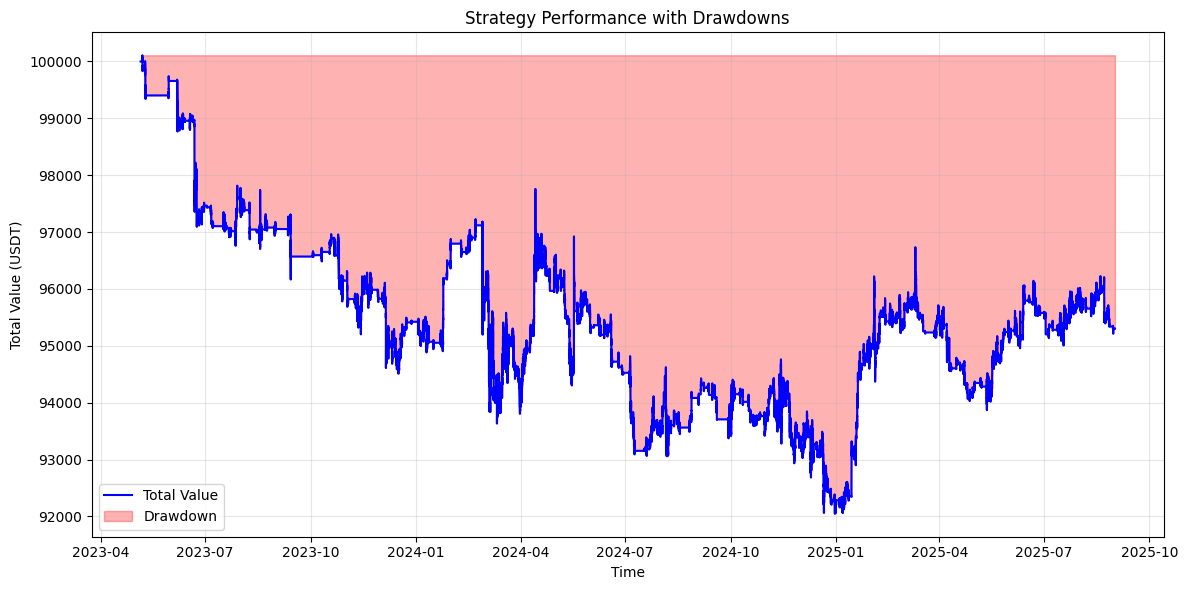

In [58]:
import pandas as pd

import matplotlib.pyplot as plt

# 计算回撤
strategy_performance['Peak'] = strategy_performance['Total Value'].cummax()
strategy_performance['Drawdown'] = strategy_performance['Total Value'] / strategy_performance['Peak'] - 1

# 标记回撤开始和结束
strategy_performance['Drawdown Start'] = (strategy_performance['Drawdown'] < 0) & (strategy_performance['Drawdown'].shift(1) == 0)
strategy_performance['Drawdown End'] = (strategy_performance['Drawdown'] == 0) & (strategy_performance['Drawdown'].shift(1) < 0)

# 提取每次回撤的开始和结束时间
drawdown_periods = []
current_start = None

for idx, row in strategy_performance.iterrows():
  if row['Drawdown Start']:
    current_start = idx
  elif row['Drawdown End'] and current_start is not None:
    drawdown_periods.append((current_start, idx))
    current_start = None

# 描述每次回撤的幅度
drawdown_descriptions = []
for start, end in drawdown_periods:
  drawdown_max = strategy_performance.loc[start:end, 'Drawdown'].min()
  drawdown_descriptions.append({
    'Start': start,
    'End': end,
    'Max Drawdown': drawdown_max
  })

# 转换为 DataFrame
drawdown_df = pd.DataFrame(drawdown_descriptions)
print("每次回撤的描述：")
print(drawdown_df)

# 可视化回撤
plt.figure(figsize=(12, 6))
plt.plot(strategy_performance['Total Value'], label='Total Value', color='blue')
plt.fill_between(strategy_performance.index, strategy_performance['Total Value'], strategy_performance['Peak'], color='red', alpha=0.3, label='Drawdown')
plt.title('Strategy Performance with Drawdowns')
plt.xlabel('Time')
plt.ylabel('Total Value (USDT)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

每次回撤的描述：
                       Start                        End  Max Drawdown
0 2023-05-07 04:34:59.999999 2023-05-07 04:39:59.999999     -0.000007
1 2023-05-07 04:44:59.999999 2023-05-07 04:54:59.999999     -0.000170
2 2023-05-07 05:04:59.999999 2023-05-07 05:14:59.999999     -0.000217
3 2023-05-07 05:19:59.999999 2023-05-07 05:29:59.999999     -0.000083
4 2023-05-07 05:34:59.999999 2023-05-07 06:14:59.999999     -0.000453
5 2023-05-07 06:19:59.999999 2023-05-07 06:24:59.999999     -0.000134


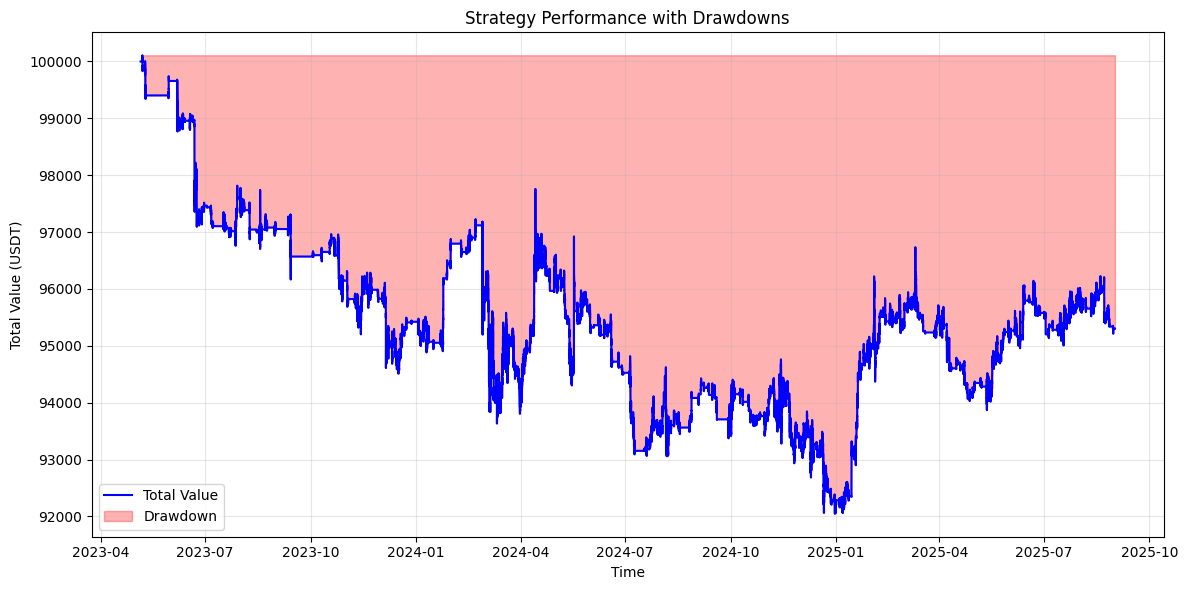

In [59]:
import pandas as pd

import matplotlib.pyplot as plt

# 计算回撤
strategy_performance['Peak'] = strategy_performance['Total Value'].cummax()
strategy_performance['Drawdown'] = strategy_performance['Total Value'] / strategy_performance['Peak'] - 1

# 标记回撤开始和结束
strategy_performance['Drawdown Start'] = (strategy_performance['Drawdown'] < 0) & (strategy_performance['Drawdown'].shift(1) == 0)
strategy_performance['Drawdown End'] = (strategy_performance['Drawdown'] == 0) & (strategy_performance['Drawdown'].shift(1) < 0)

# 提取每次回撤的开始和结束时间
drawdown_periods = []
current_start = None

for idx, row in strategy_performance.iterrows():
  if row['Drawdown Start']:
    current_start = idx
  elif row['Drawdown End'] and current_start is not None:
    drawdown_periods.append((current_start, idx))
    current_start = None

# 描述每次回撤的幅度
drawdown_descriptions = []
for start, end in drawdown_periods:
  drawdown_max = strategy_performance.loc[start:end, 'Drawdown'].min()
  drawdown_descriptions.append({
    'Start': start,
    'End': end,
    'Max Drawdown': drawdown_max
  })

# 转换为 DataFrame
drawdown_df = pd.DataFrame(drawdown_descriptions)
print("每次回撤的描述：")
print(drawdown_df)

# 可视化回撤
plt.figure(figsize=(12, 6))
plt.plot(strategy_performance['Total Value'], label='Total Value', color='blue')
plt.fill_between(strategy_performance.index, strategy_performance['Total Value'], strategy_performance['Peak'], color='red', alpha=0.3, label='Drawdown')
plt.title('Strategy Performance with Drawdowns')
plt.xlabel('Time')
plt.ylabel('Total Value (USDT)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
''

''

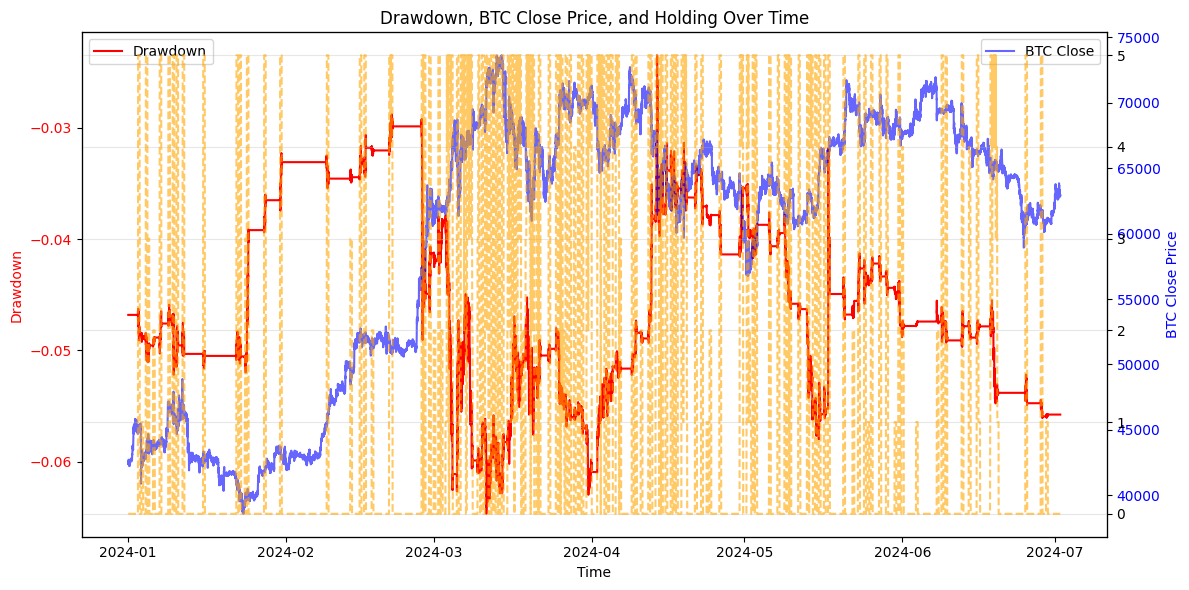

In [61]:
import matplotlib.pyplot as plt

# 定义时间筛选范围
start_time = '2024-01-01'
end_time = '2024-07-01'

# 筛选数据
filtered_strategy_performance = strategy_performance.loc[start_time:end_time]
filtered_btc = btc.loc[start_time:end_time]
filtered_holding = holding.loc[start_time:end_time]

plt.figure(figsize=(12, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# 绘制 Drawdown
ax1.plot(filtered_strategy_performance.index, filtered_strategy_performance['Drawdown'], label='Drawdown', color='red')
ax1.set_ylabel('Drawdown', color='red')
ax1.tick_params(axis='y', labelcolor='red')

# 绘制 BTC 的 Close 列
ax2.plot(filtered_btc.index, filtered_btc['Close'], label='BTC Close', color='blue', alpha=0.6)
ax2.set_ylabel('BTC Close Price', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# 绘制 Holding
ax3.plot(filtered_holding.index, filtered_holding.values, label='Holding', color='orange', alpha=0.6, linestyle='--')

# 设置标题和网格
plt.title('Drawdown, BTC Close Price, and Holding Over Time')
ax1.set_xlabel('Time')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

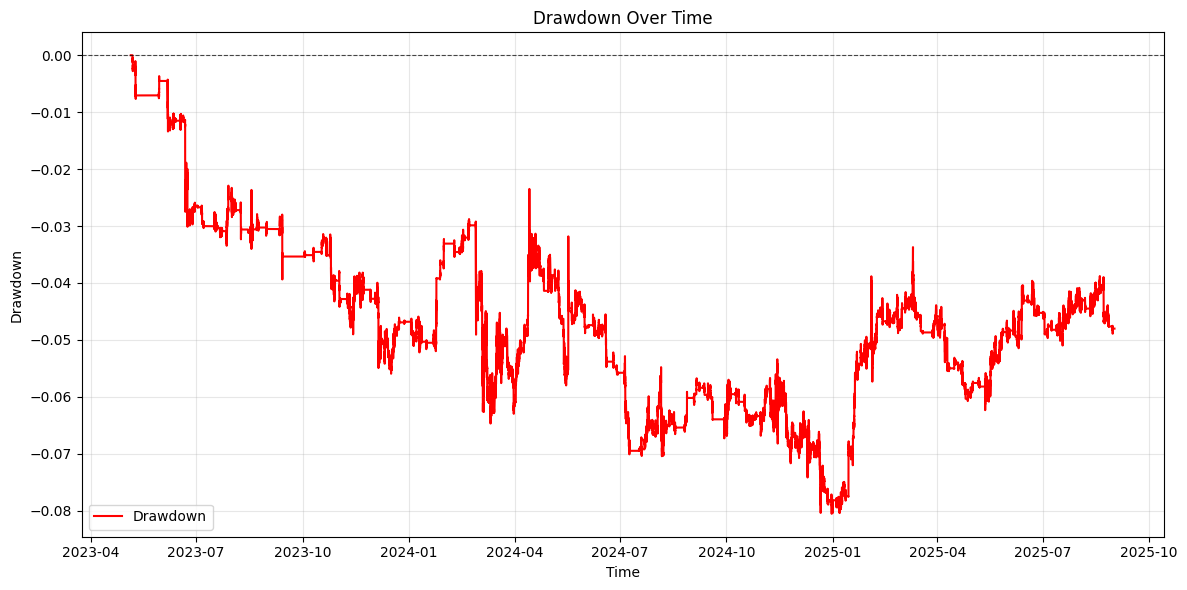

In [62]:
import matplotlib.pyplot as plt

# 绘制回撤
plt.figure(figsize=(12, 6))
plt.plot(strategy_performance['Drawdown'], label='Drawdown', color='red')
plt.title('Drawdown Over Time')
plt.xlabel('Time')
plt.ylabel('Drawdown')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.7)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [63]:
strategy_performance.to_csv("sp.csv")